---
# **EDA and Pre-Processing Flight Data**
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_or = pd.read_csv('combined_csv_data.csv', low_memory=False)

In [3]:
data_or

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
0,1477057155,a45cef,33.79508256912231,-84.47507858276367,247.890380859375,347.9974365234375,NaN,NaN,False,False,False,NaN,NaN,9776.46,1.477057e+09,1.477057e+09,1.477055e+09
1,1477057156,a45cef,33.79508256912231,-84.47507858276367,247.890380859375,347.9974365234375,NaN,NaN,False,False,False,NaN,NaN,9776.46,1.477057e+09,1.477057e+09,1.477055e+09
2,1477057157,a45cef,33.79508256912231,-84.47507858276367,247.890380859375,347.9974365234375,NaN,NaN,False,False,False,NaN,NaN,9776.46,1.477057e+09,1.477057e+09,1.477055e+09
3,1477057158,a45cef,33.79508256912231,-84.47507858276367,247.890380859375,347.9974365234375,NaN,NaN,False,False,False,NaN,NaN,9776.46,1.477057e+09,1.477057e+09,1.477055e+09
4,1477057159,a45cef,33.79508256912231,-84.47507858276367,247.890380859375,347.9974365234375,NaN,NaN,False,False,False,NaN,NaN,9776.46,1.477057e+09,1.477057e+09,1.477055e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23530647,1585086964,a80a97,33.82518186407574,-84.47805404663086,195.6490795284855,349.5469286562046,-0.32511999999999996,ASQ4014,False,False,False,3706.0,11582.4,11940.54,1.585087e+09,1.585087e+09,1.585084e+09
23530648,1585086965,a80a97,33.82713705806409,-84.47845458984375,195.1431956445805,349.5195244812953,0.0,ASQ4014,False,False,False,3706.0,11582.4,11940.54,1.585087e+09,1.585087e+09,1.585084e+09
23530649,1585086966,a80a97,33.830245971679695,-84.47914590640943,195.1431956445805,349.5195244812953,0.0,ASQ4014,False,False,False,3706.0,11582.4,11940.54,1.585087e+09,1.585087e+09,1.585084e+09
23530650,1585086967,a80a97,33.83175659179688,-84.47948222257651,195.1431956445805,349.5195244812953,0.0,ASQ4014,False,False,False,3706.0,11582.4,11940.54,1.585087e+09,1.585087e+09,1.585084e+09


---

## **1. Data Wrangling and DType Conversion**

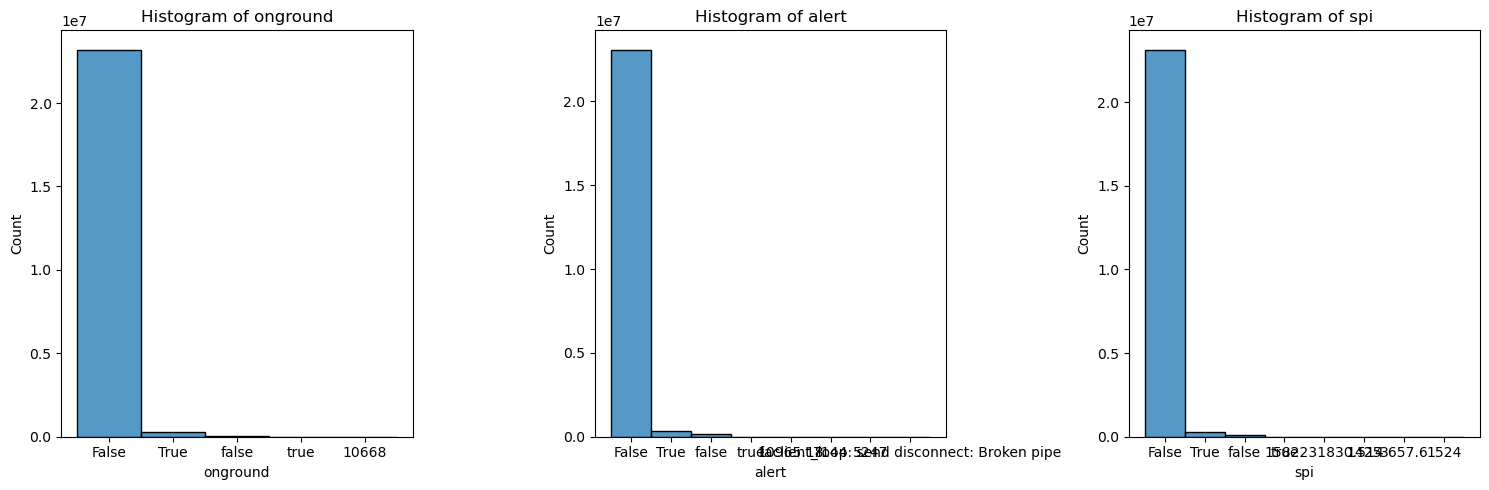

In [4]:
# Draw histograms for boolean columns
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(data=data_or, x='onground', bins=2, kde=False)
plt.title('Histogram of onground')

plt.subplot(1, 3, 2)
sns.histplot(data=data_or, x='alert', bins=2, kde=False)
plt.title('Histogram of alert')

plt.subplot(1, 3, 3)
sns.histplot(data=data_or, x='spi', bins=2, kde=False)
plt.title('Histogram of spi')

plt.tight_layout()
plt.show()

In [5]:
boolean_columns = ['onground', 'alert', 'spi']
for col in boolean_columns:
    print(f"Unique values in column {col}:")
    print(data_or[col].unique())

Unique values in column onground:
['False' 'True' nan 'false' 'true' '10668']
Unique values in column alert:
['False' 'True' nan 'false' 'true' '10965.18' '7144' '5247'
 'faclient_loop: send disconnect: Broken pipe']
Unique values in column spi:
['False' 'True' nan 'false' 'true' '1582231830.514' '1425' '3657.6' '1524']


In [6]:
data_or.isna().sum()

time                   0
icao24                 0
lat                    0
lon                    0
velocity           77150
heading            77150
vertrate           76773
callsign         1763395
onground               1
alert                  1
spi                    3
squawk           6665874
baroaltitude      203931
geoaltitude       522712
lastposupdate          3
lastcontact            6
hour                   8
dtype: int64

In [7]:
data = data_or.copy()

In [8]:
def check_mixed_types(df):
    mixed_columns = {}
    for col in df.columns:
        types = df[col].apply(type).value_counts()
        if len(types) > 1:
            mixed_columns[col] = types
    return mixed_columns

mixed_columns = check_mixed_types(data)
mixed_columns

{'velocity': velocity
 <class 'str'>      23453502
 <class 'float'>       77150
 Name: count, dtype: int64,
 'heading': heading
 <class 'str'>      23453502
 <class 'float'>       77150
 Name: count, dtype: int64,
 'vertrate': vertrate
 <class 'str'>      23453879
 <class 'float'>       76773
 Name: count, dtype: int64,
 'callsign': callsign
 <class 'str'>      21767257
 <class 'float'>     1763395
 Name: count, dtype: int64,
 'onground': onground
 <class 'str'>      23530651
 <class 'float'>           1
 Name: count, dtype: int64,
 'alert': alert
 <class 'str'>      23530651
 <class 'float'>           1
 Name: count, dtype: int64,
 'spi': spi
 <class 'str'>      23530649
 <class 'float'>           3
 Name: count, dtype: int64,
 'geoaltitude': geoaltitude
 <class 'str'>      23007940
 <class 'float'>      522712
 Name: count, dtype: int64}

In [9]:
boolean_columns = ['onground', 'alert', 'spi']

def convert_to_boolean(df, col):
    valid_values = {'True', 'False', 'true', 'false'}
    df[col] = df[col].apply(lambda x: x if x in valid_values else pd.NA)
    df[col] = df[col].map({'True': True, 'False': False, 'true': True, 'false': False, '<NA>' : None})
    return df

for col in boolean_columns:
    data = convert_to_boolean(data, col)
    print(f"After conversion, unique values in column {col}:")
    print(data[col].unique())


After conversion, unique values in column onground:
[False True nan]
After conversion, unique values in column alert:
[False True nan]
After conversion, unique values in column spi:
[False True nan]


In [10]:
# Dictionary dtype for each column
target_dtypes = {
    'lat': 'float',
    'lon': 'float',
    'velocity': 'float',
    'heading': 'float',
    'vertrate': 'float',
    'onground': 'bool',
    'alert': 'bool',
    'spi': 'bool',
    'geoaltitude': 'float'
}

# Convert columns to target dtypes
def convert_dtype(df, col, dtype):
    if dtype == 'float':
        df[col] = pd.to_numeric(df[col], errors='coerce')
    elif dtype == 'bool':
        df[col] = df[col].replace({'True': True, 'False': False, np.nan: np.nan}).astype('boolean')
    elif dtype == 'str':
        df[col] = df[col].astype('str')
    return df

for col, dtype in target_dtypes.items():
    data = convert_dtype(data, col, dtype)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23530652 entries, 0 to 23530651
Data columns (total 17 columns):
 #   Column         Dtype  
---  ------         -----  
 0   time           int64  
 1   icao24         object 
 2   lat            float64
 3   lon            float64
 4   velocity       float64
 5   heading        float64
 6   vertrate       float64
 7   callsign       object 
 8   onground       boolean
 9   alert          boolean
 10  spi            boolean
 11  squawk         float64
 12  baroaltitude   float64
 13  geoaltitude    float64
 14  lastposupdate  float64
 15  lastcontact    float64
 16  hour           float64
dtypes: boolean(3), float64(11), int64(1), object(2)
memory usage: 2.6+ GB


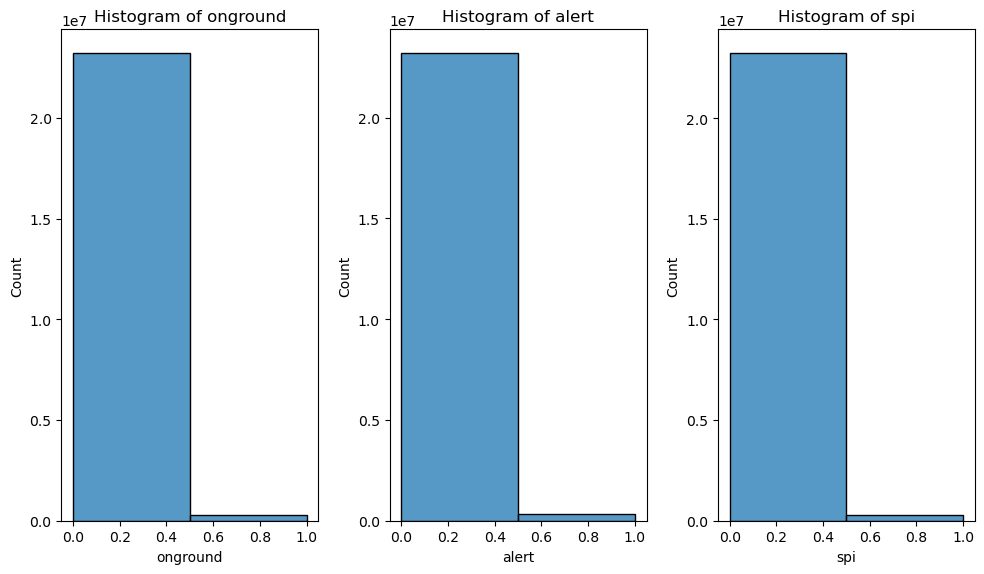

In [12]:
# Draw histograms for boolean columns
plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
sns.histplot(data=data, x='onground', bins=2, kde=False)
plt.title('Histogram of onground')

plt.subplot(1, 3, 2)
sns.histplot(data=data, x='alert', bins=2, kde=False)
plt.title('Histogram of alert')

plt.subplot(1, 3, 3)
sns.histplot(data=data, x='spi', bins=2, kde=False)
plt.title('Histogram of spi')

plt.tight_layout()
plt.show()

**Dữ liệu chuyến bay có các cột sau đây, mỗi cột mang một ý nghĩa cụ thể liên quan đến thông tin của chuyến bay:**

time (int64): Thời gian của bản ghi, thời gian tính bằng giây kể từ epoch (Unix timestamp).

icao24 (object): Mã định danh 24-bit của máy bay, là duy nhất cho mỗi máy bay và được cấp phát bởi ICAO.

lat (float64): Vĩ độ của vị trí hiện tại của máy bay.

lon (float64): Kinh độ của vị trí hiện tại của máy bay.

velocity (float64): Tốc độ của máy bay tính bằng mét/giây.

heading (float64): Hướng đi của máy bay tính bằng độ, từ 0 đến 360 độ.

vertrate (float64): Tốc độ thay đổi độ cao của máy bay, tính bằng feet/phút.

callsign (object): Mã hiệu (callsign) của chuyến bay, thường là số hiệu chuyến bay do hãng hàng không cấp phát.

onground (bool): Trạng thái của máy bay, cho biết máy bay đang ở trên mặt đất (True) hay không (False).

alert (bool): Trạng thái báo động, cho biết máy bay đang ở trong tình trạng báo động (True) hay không (False).

spi (bool): Special Position Indicator, cho biết máy bay có đang phát tín hiệu vị trí đặc biệt (True) hay không (False).

squawk (float64): Mã squawk của máy bay, là mã transponder dùng để nhận dạng máy bay hoặc chỉ báo các tình huống đặc biệt.

baroaltitude (float64): Độ cao so với mặt biển theo áp suất khí quyển (barometric altitude), tính bằng mét.

geoaltitude (float64): Độ cao thực tế so với mực nước biển (geometric altitude), tính bằng mét.

lastposupdate (float64): Thời gian cập nhật vị trí cuối cùng, tính bằng giây kể từ epoch, thời gian tính bằng giây kể từ epoch (Unix timestamp).

lastcontact (float64): Thời gian liên lạc cuối cùng với hệ thống giám sát, tính bằng giây kể từ epoch, thời gian tính bằng giây kể từ epoch (Unix timestamp).

hour (float64): Giá trị giờ của bản ghi, tính bằng giây kể từ epoch, thời gian tính bằng giây kể từ epoch (Unix timestamp).

---

## **2. Missing Value Imputation**

In [13]:
data.isnull().sum()

time                   0
icao24                 0
lat                    1
lon                    1
velocity           77151
heading            77153
vertrate           76777
callsign         1763395
onground               2
alert                  5
spi                    7
squawk           6665874
baroaltitude      203931
geoaltitude       522713
lastposupdate          3
lastcontact            6
hour                   8
dtype: int64

<Axes: >

/Users/dningg/tensorflow-apple-metal/env/lib/python3.10/site-packages/matplotlib/image.py:181: UserWarning: Data with more than 2**24 rows cannot be accurately displayed. Downsampling to less than 2**24 rows before displaying. To remove this warning, manually downsample your data.
  warnings.warn(msg.format(n='2**24 rows'))


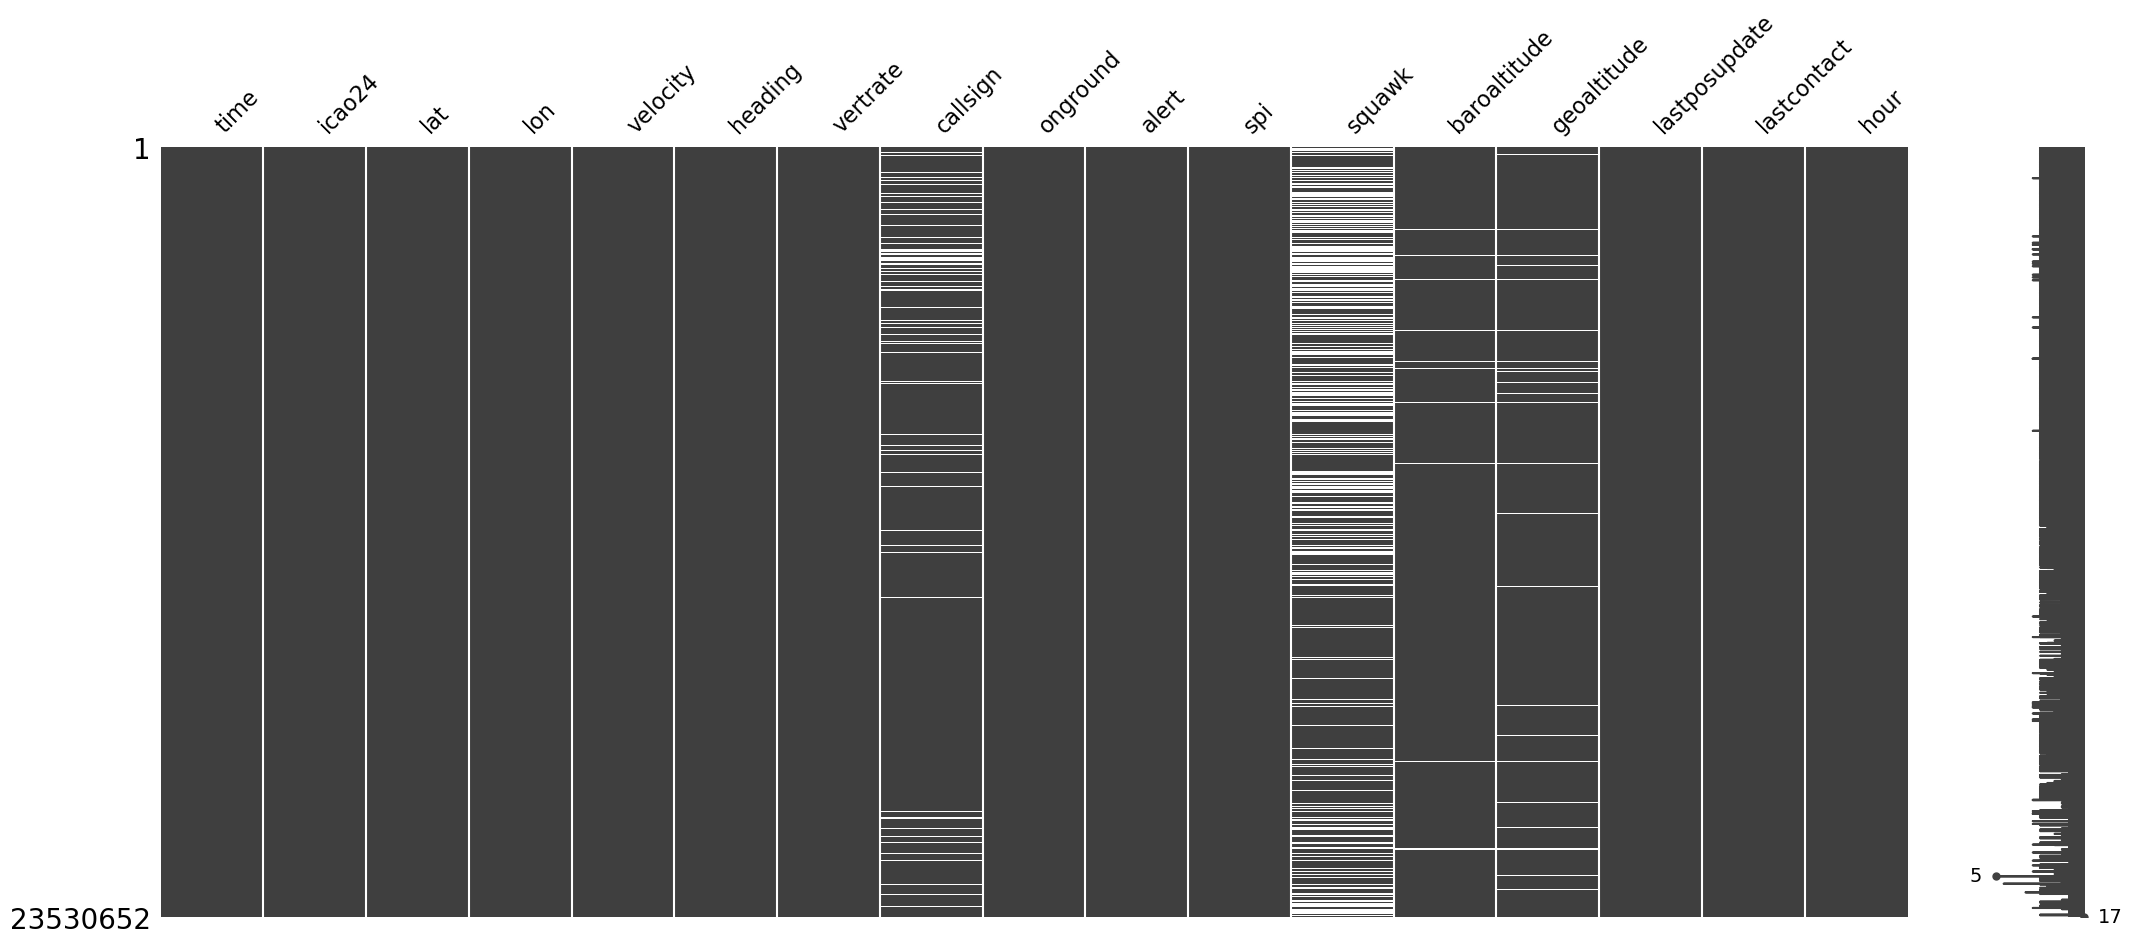

In [14]:
import missingno as msno
msno.matrix(data)

**Explanation of Missing Values Handling**
Given the dataset summary with approximately 23.5 million rows:

- *time, icao24*: These columns have no missing values.

- *lat, lon:* Each has 1 missing value. These missing values can be handled by either imputation or deletion depending on the context and impact on the analysis.

- *velocity, heading, vertrate*: These columns have a significant number of missing values: 77,151 for velocity, 77,153 for heading, and 76,777 for vertrate. Imputation strategies may vary based on data characteristics - and modeling requirements.

- *callsign*: Contains 1,763,395 missing values. Rows without a callsign can be dropped since it's a substantial proportion of the data.

- *onground, alert, spi*: These boolean columns have very few missing values (2, 5, and 7 respectively). These can be handled by imputation or treated as missing depending on their importance to the analysis.

- *squawk*: This column has an overwhelming number of missing values (6,665,874). Given its high proportion, its impact on the analysis needs careful consideration. Depending on its relevance to the problem at hand (flight trajectory prediction and anomaly detection), rows with missing squawk values might be excluded or imputed cautiously.

- *baroaltitude, geoaltitude, lastposupdate, lastcontact, hour*: These columns have missing values as well, with baroaltitude having 203,931 missing values and geoaltitude having 522,713 missing values. These can be handled similarly to lat and lon, based on their impact on the analysis.

**Data Handling Strategy:**
- Drop rows without callsign: Since callsign is missing in a large number of cases (1,763,395 rows), these rows can be safely removed from the dataset.

- Investigate missing values in squawk: Given the vast number of missing values (6,665,874), further investigation is necessary to determine its impact. If squawk data is not critical for your analysis (flight trajectory prediction and anomaly detection), consider dropping or imputing cautiously.

- Handle remaining missing values: For columns with fewer missing values (lat, lon, velocity, heading, vertrate, onground, alert, spi, baroaltitude, geoaltitude, lastposupdate, lastcontact, hour), apply appropriate imputation techniques based on their distribution and importance to the analysis.



### **Delete**

In [15]:
data = data.dropna(subset=['callsign'])
data

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
43,1478874137,aaa83f,33.798321,-84.475651,221.557599,348.481341,-0.32512,EJA786,False,False,False,7771.0,12184.38,NaN,1.478874e+09,1.478874e+09,1.478873e+09
44,1478874138,aaa83f,33.798321,-84.475651,221.557599,348.481341,-0.32512,EJA786,False,False,False,7771.0,12184.38,NaN,1.478874e+09,1.478874e+09,1.478873e+09
45,1478874139,aaa83f,33.798321,-84.475651,221.557599,348.481341,-0.32512,EJA786,False,False,False,7771.0,12184.38,NaN,1.478874e+09,1.478874e+09,1.478873e+09
46,1478874140,aaa83f,33.798321,-84.475651,221.557599,348.481341,-0.32512,EJA786,False,False,False,7771.0,12184.38,NaN,1.478874e+09,1.478874e+09,1.478873e+09
47,1478874141,aaa83f,33.798321,-84.475651,221.557599,348.481341,-0.32512,EJA786,False,False,False,7771.0,12184.38,NaN,1.478874e+09,1.478874e+09,1.478873e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23530647,1585086964,a80a97,33.825182,-84.478054,195.649080,349.546929,-0.32512,ASQ4014,False,False,False,3706.0,11582.40,11940.54,1.585087e+09,1.585087e+09,1.585084e+09
23530648,1585086965,a80a97,33.827137,-84.478455,195.143196,349.519524,0.00000,ASQ4014,False,False,False,3706.0,11582.40,11940.54,1.585087e+09,1.585087e+09,1.585084e+09
23530649,1585086966,a80a97,33.830246,-84.479146,195.143196,349.519524,0.00000,ASQ4014,False,False,False,3706.0,11582.40,11940.54,1.585087e+09,1.585087e+09,1.585084e+09
23530650,1585086967,a80a97,33.831757,-84.479482,195.143196,349.519524,0.00000,ASQ4014,False,False,False,3706.0,11582.40,11940.54,1.585087e+09,1.585087e+09,1.585084e+09


In [16]:
data.isnull().sum()


time                   0
icao24                 0
lat                    1
lon                    1
velocity           23440
heading            23441
vertrate           23360
callsign               0
onground               1
alert                  4
spi                    6
squawk           5118616
baroaltitude      190265
geoaltitude       392549
lastposupdate          2
lastcontact            5
hour                   7
dtype: int64

In [17]:
def count_nulls_per_group(df):
    columns_to_check = ['lat', 'lon', 'velocity', 'heading', 'vertrate','onground','alert', 'spi', 'baroaltitude', 'geoaltitude', 'lastposupdate', 'lastcontact', 'hour']
    grouped = df.groupby(['icao24','callsign'])[columns_to_check].apply(lambda x: x.isnull().sum())
    return grouped

In [18]:
null_counts_grouped = count_nulls_per_group(data)
null_counts_grouped

,,lat,lon,velocity,heading,vertrate,onground,alert,spi,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
icao24,callsign,,,,,,,,,,,,,
00008f,XAFLC,0,0,0,0,0,0,0,0,0,0,0,0,0
030012,F001,0,0,0,0,0,0,0,0,0,0,0,0,0
04008b,ETH3519,0,0,0,0,0,0,0,0,0,0,0,0,0
06a05a,A7AAH,0,0,0,0,0,0,0,0,0,0,0,0,0
06a066,QTR713,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
e80242,LNE1436,0,0,0,0,0,0,0,0,0,0,0,0,0
e8044e,LAN532,0,0,0,0,0,0,0,0,0,0,0,0,0
e8066c,FACH996,0,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
null_counts_grouped = null_counts_grouped[(null_counts_grouped.T != 0).any()]
null_counts_grouped

,,lat,lon,velocity,heading,vertrate,onground,alert,spi,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
icao24,callsign,,,,,,,,,,,,,
06a0dd,QTR8131,0,0,0,0,0,0,0,0,0,1,0,0,0
06a0de,QTR8131,0,0,0,0,0,0,0,0,0,1,0,0,0
06a0df,QTR8143,0,0,1,1,1,0,0,0,0,1,0,0,0
06a10b,QTR777,0,0,0,0,0,0,0,0,1,1,0,0,0
06a1e8,QTR8143,0,0,0,0,0,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c080a6,WJA2690,0,0,0,0,0,0,0,0,0,1,0,0,0
c080ac,WJA2641,0,0,0,0,0,0,0,0,0,1,0,0,0
c080ae,WJA2624,0,0,0,0,0,0,0,0,0,2,0,0,0


In [20]:
null_indices = null_counts_grouped.index.tolist()
data_after_del = data[~data.set_index(['icao24', 'callsign']).index.isin(null_indices)].reset_index(drop=True)

print("Data after removing rows with matching 'icao24', 'callsign' from null_counts_grouped:")
data_after_del

Data after removing rows with matching 'icao24', 'callsign' from null_counts_grouped:


,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
0,1478875626,a1fb8f,33.755679,-84.465466,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
1,1478875627,a1fb8f,33.757645,-84.465917,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
2,1478875628,a1fb8f,33.758743,-84.466198,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
3,1478875629,a1fb8f,33.761536,-84.466870,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11590.02,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
4,1478875630,a1fb8f,33.763733,-84.467411,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13351523,1585086885,a48321,33.812473,-84.389706,210.927686,89.580770,11.70432,DAL1886,False,False,False,2062.0,3817.62,3901.44,1.585087e+09,1.585087e+09,1.585084e+09
13351524,1585086886,a48321,33.812520,-84.386730,210.932078,89.441035,11.70432,DAL1886,False,False,False,2062.0,3825.24,3916.68,1.585087e+09,1.585087e+09,1.585084e+09
13351525,1585086887,a48321,33.812520,-84.384441,210.932078,89.441035,12.02944,DAL1886,False,False,False,2062.0,3840.48,3924.30,1.585087e+09,1.585087e+09,1.585084e+09
13351526,1585086888,a48321,33.812520,-84.382381,211.960917,89.443748,12.02944,DAL1886,False,False,False,2062.0,3848.10,3931.92,1.585087e+09,1.585087e+09,1.585084e+09


In [21]:
data_after_del.isnull().sum()

time                   0
icao24                 0
lat                    0
lon                    0
velocity               0
heading                0
vertrate               0
callsign               0
onground               0
alert                  0
spi                    0
squawk           2621739
baroaltitude           0
geoaltitude            0
lastposupdate          0
lastcontact            0
hour                   0
dtype: int64

### **Squawk Code**

Types of Squawk Codes
Squawk codes include a range of numbers from 0000 to 7777, with specific codes or ranges designated for particular purposes:

General Codes: Assigned by ATC for individual flights based on their flight plan and airspace through which they are flying.

Discrete Codes: Unique codes assigned to a specific flight critical for individual tracking and identification in congested airspace.

Emergency Codes: Universally recognized codes that indicate specific emergencies:

- 7500: Indicates hijacking or unlawful interference.

- 7600: Signifies a loss of communication (radio failure).

- 7700: Used for general emergencies requiring immediate assistance.

Special Codes: For example, 2000 for aircraft operating under VFR (Visual Flight Rules) without a specific ATC-assigned code or 1200 in the US for the same purpose.

In [22]:
def count_squawk_outliers(data):
    count_outliers = 0
    for squawk in data:
        if squawk < 0 or squawk > 7777:
            count_outliers += 1
    return count_outliers

def emergency_squawk(data):
    count_emergency = 0
    for squawk in data:
        if squawk == 7500 or squawk == 7600 or squawk == 7700:
            count_emergency += 1
    return count_emergency

outliers = count_squawk_outliers(data_after_del['squawk'])
print("Number of rows with squawk values less than 0 or greater than 7777:", outliers)

emergency = emergency_squawk(data_after_del['squawk'])
print("Number of rows with squawk values 7500, 7600 or 7700:", emergency)

Number of rows with squawk values less than 0 or greater than 7777: 0
Number of rows with squawk values 7500, 7600 or 7700: 2545


In [23]:
def aggregate_emergency_counts(df):
    # Filter rows with emergency squawk codes
    emergency_df = df[df['squawk'].isin([7500, 7600, 7700])]
    grouped = emergency_df.pivot_table(index=['icao24', 'callsign'], columns='squawk', aggfunc='size', fill_value=0)
    grouped = grouped.reset_index()
    grouped.columns.name = None
    grouped = grouped.rename(columns={7500: 'squawk_7500', 7600: 'squawk_7600', 7700: 'squawk_7700'})
    unique_values = df.groupby(['icao24', 'callsign']).agg({
        'spi': 'nunique',
        'alert': 'nunique'
    }).reset_index()
    grouped = pd.merge(grouped, unique_values, on=['icao24', 'callsign'])
    return grouped

ef_grouped = aggregate_emergency_counts(data_after_del)
ef_grouped


,icao24,callsign,squawk_7500,squawk_7600,squawk_7700,spi,alert
0,3c70c2,GEC8220,0,13,0,1,2
1,a03448,N112GS,80,0,0,1,1
2,a03816,RPA4530,0,44,0,1,1
3,a051d7,N12FA,0,70,0,1,1
4,a0cfbd,AAL742,42,0,0,2,1
5,a0e291,N156XL,0,14,0,1,2
6,a1dc31,AAY412,0,0,23,1,1
7,a2105a,N232EH,0,0,182,1,2
8,a2c087,ASA784,67,0,0,1,1
9,a35aae,AAL2602,0,10,0,1,1


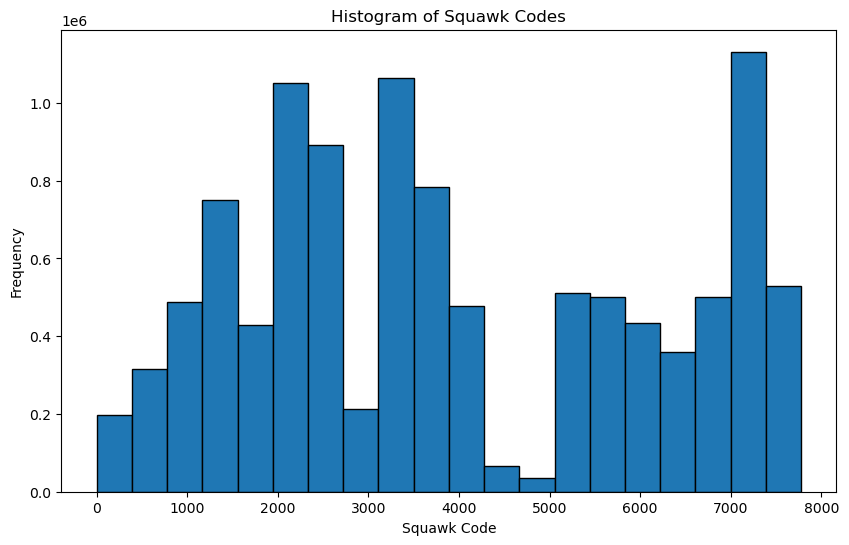

In [24]:
plt.figure(figsize=(10, 6))
plt.hist(data_after_del['squawk'], bins=20, edgecolor='black')
plt.title('Histogram of Squawk Codes')
plt.xlabel('Squawk Code')
plt.ylabel('Frequency')
plt.show()

---
## **3. Exploratory Data Analysis**

### Correlation Matrix

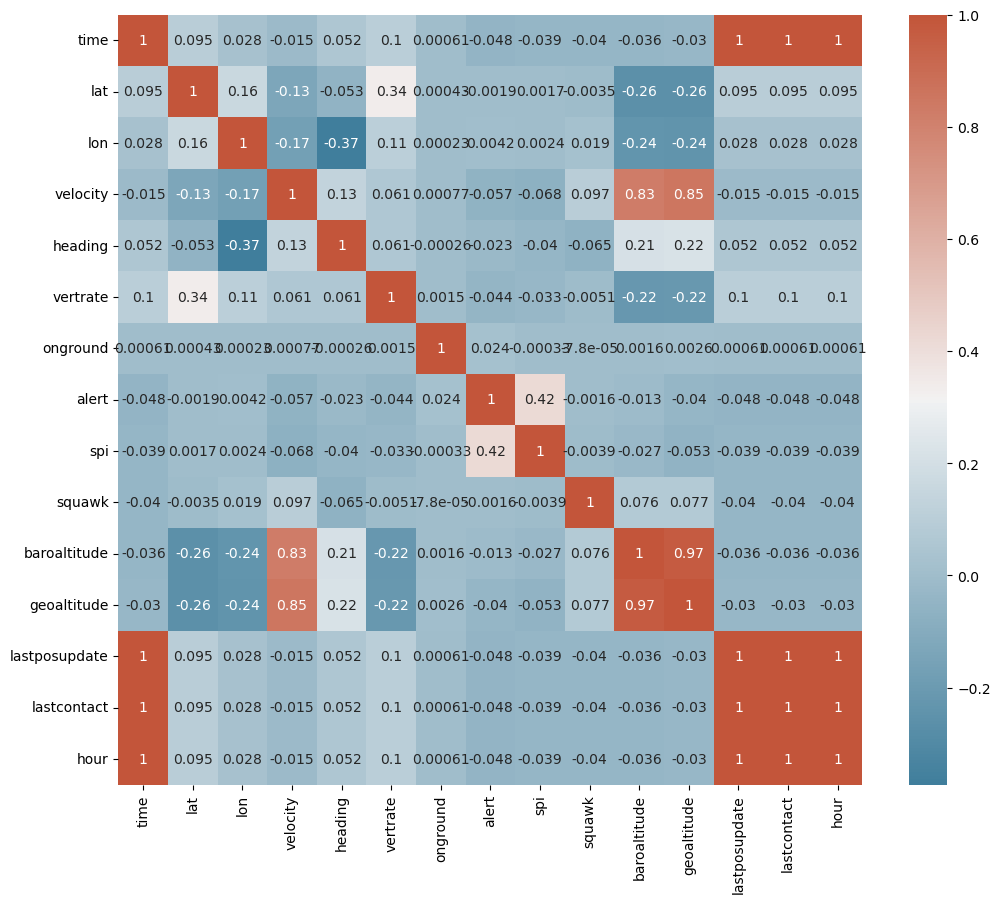

In [91]:
df_corr = data_after_del.drop(columns=['icao24', 'callsign'])

plt.figure(figsize=(12,10))
cor = df_corr.corr()
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(cor, annot=True, cmap=cmap)
plt.show()


### Boxplot Diagram

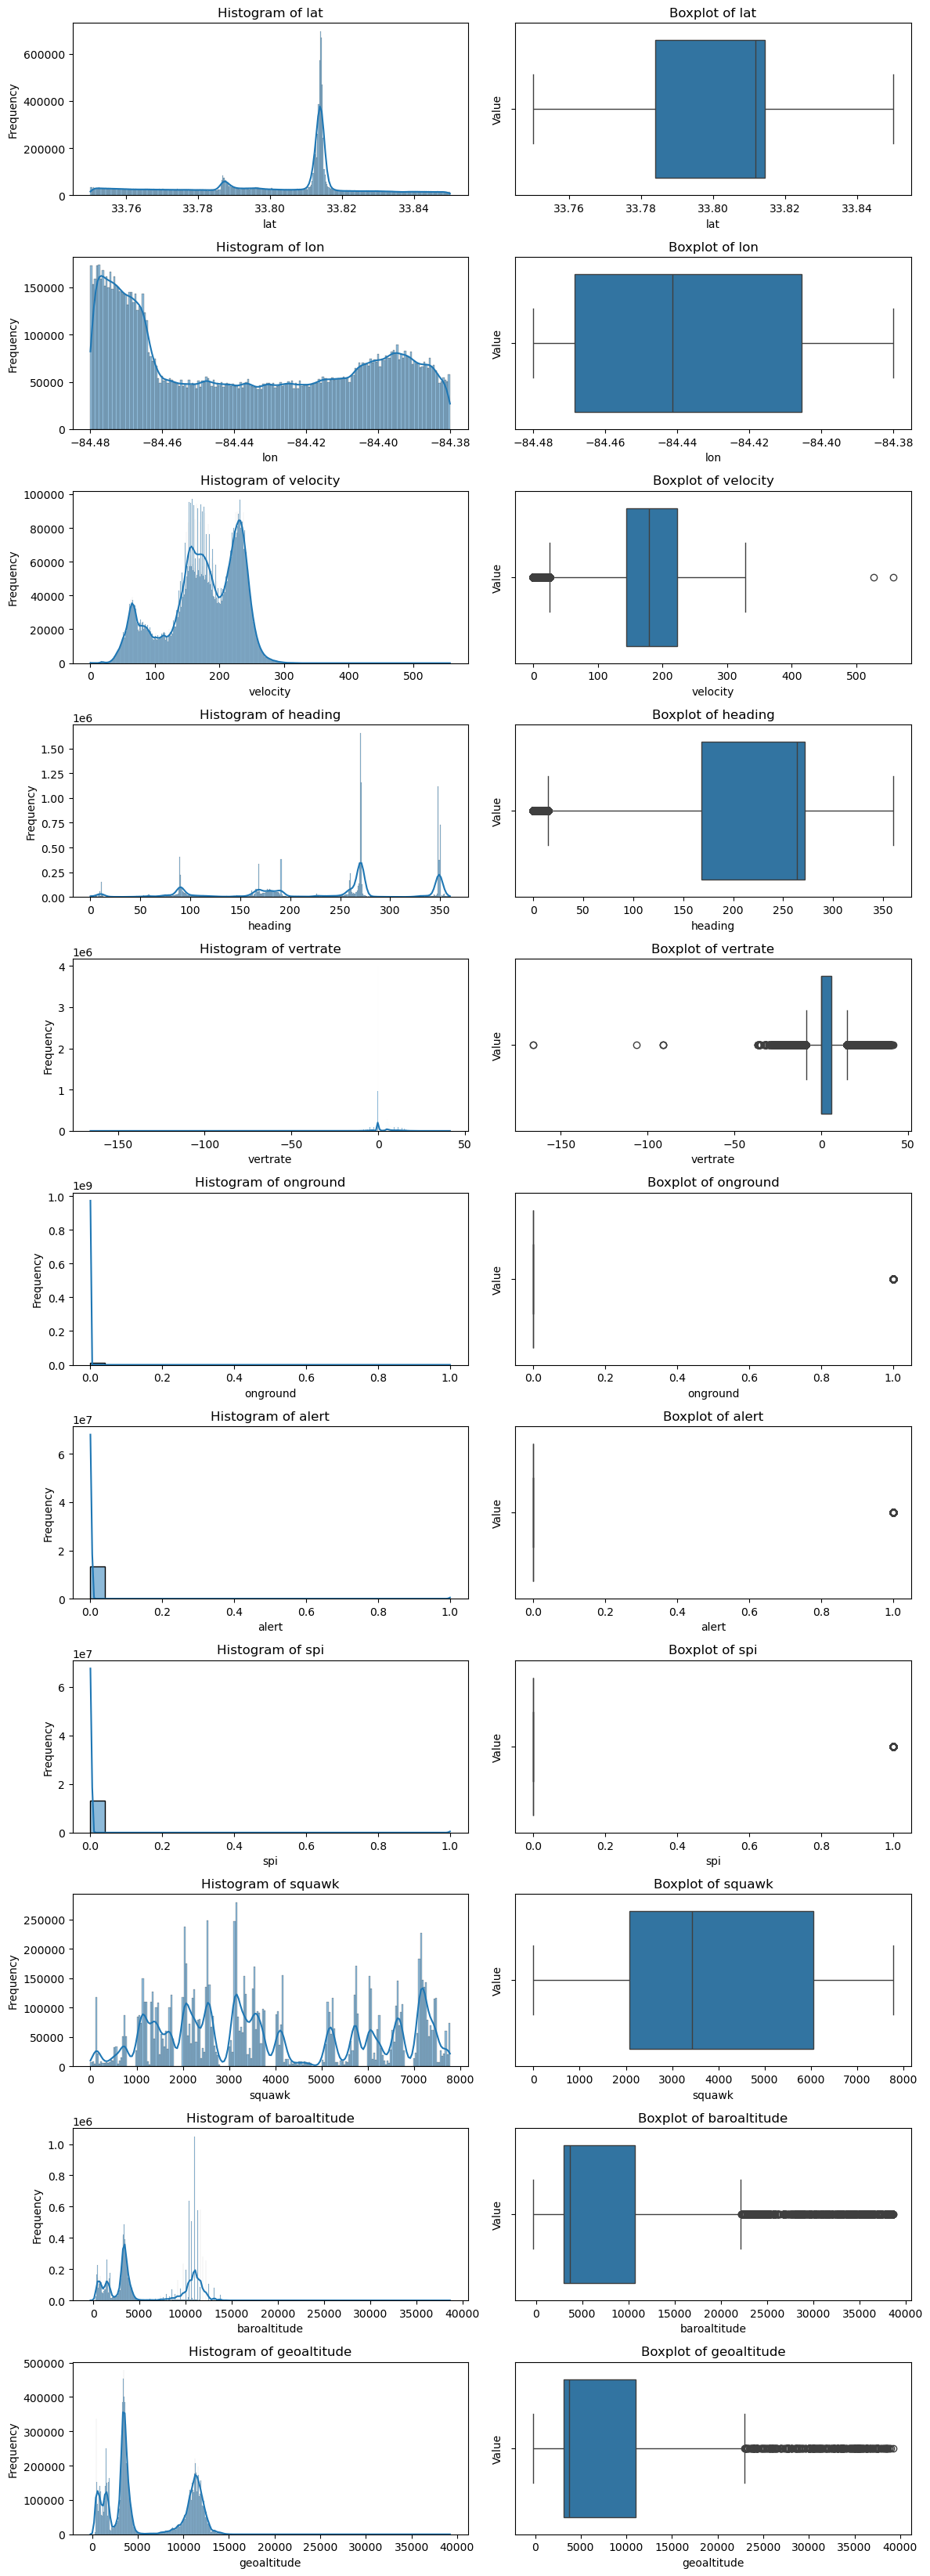

In [25]:
columns_to_plot = ['lat', 'lon', 'velocity', 'heading', 'vertrate',
                   'onground', 'alert', 'spi', 'squawk', 'baroaltitude', 'geoaltitude']

fig, axes = plt.subplots(nrows=len(columns_to_plot), ncols=2, figsize=(12, 3*len(columns_to_plot)))

for i, col in enumerate(columns_to_plot):
    sns.histplot(data_after_del[col].dropna(), ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f'Histogram of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    sns.boxplot(x=data_after_del[col].dropna(), ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

---

## **4. Check Flight Information**

In [26]:
import requests
from bs4 import BeautifulSoup

def info_flight(callsigns):
    results = {}
    
    # Create a session to persist certain parameters across requests
    session = requests.Session()

    # Set the base URL and headers to mimic a browser request
    base_url = "https://www.flightaware.com/resources/registration/"
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.5',
        'Referer': 'https://www.google.com',
        'Connection': 'keep-alive',
        'Upgrade-Insecure-Requests': '1'
    }

    for callsign in callsigns:
        url = base_url + callsign
        try:
            # Make the HTTP request with headers
            response = session.get(url, headers=headers)
            # Check the HTTP response status
            if response.status_code == 200:
                # Parse the HTML content
                soup = BeautifulSoup(response.text, 'html.parser')
                # Find the specific section containing the aircraft type
                aircraft_summary = soup.find("div", {"class": "medium-3 columns"})
                # Extract the aircraft type if available
                if aircraft_summary:
                    aircraft_type = aircraft_summary.get_text(strip=True)
                    results[callsign] = aircraft_type
                else:
                    results[callsign] = "Aircraft type not found"
            else:
                results[callsign] = f"Error: HTTP status code {response.status_code}"
        except Exception as e:
            results[callsign] = f"Error: {str(e)}"
    
    return results

In [40]:
def info_flight_single(callsign):
    base_url = "https://www.flightaware.com/resources/registration/"
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.5',
        'Referer': 'https://www.google.com',
        'Connection': 'keep-alive',
        'Upgrade-Insecure-Requests': '1'
    }

    url = base_url + callsign
    try:
        # Make the HTTP request with headers
        response = requests.get(url, headers=headers)
        # Check the HTTP response status
        if response.status_code == 200:
            # Parse the HTML content
            soup = BeautifulSoup(response.text, 'html.parser')
            # Find the specific section containing the aircraft type
            aircraft_summary = soup.find("div", {"class": "medium-3 columns"})
            # Extract the aircraft type if available
            if aircraft_summary:
                aircraft_type = aircraft_summary.get_text(strip=True)
                return aircraft_type
            else:
                return "Aircraft type not found"
        else:
            return f"Error: HTTP status code {response.status_code}"
    except Exception as e:
        return f"Error: {str(e)}"

ef_grouped['info'] = ef_grouped['callsign'].apply(info_flight_single)
ef_grouped

,icao24,callsign,squawk_7500,squawk_7600,squawk_7700,spi,alert,info
0,3c70c2,GEC8220,0,13,0,1,2,Aircraft type not found
1,a03448,N112GS,80,0,0,1,1,2002 CESSNA 525AFixed wing multi engine(8 seat...
2,a03816,RPA4530,0,44,0,1,1,Aircraft type not found
3,a051d7,N12FA,0,70,0,1,1,1995 PILATUS AIRCRAFT LTD PC-12Fixed wing sing...
4,a0cfbd,AAL742,42,0,0,2,1,Aircraft type not found
5,a0e291,N156XL,0,14,0,1,2,2010 CESSNA 560XLFixed wing multi engine(13 se...
6,a1dc31,AAY412,0,0,23,1,1,Aircraft type not found
7,a2105a,N232EH,0,0,182,1,2,RAYTHEON AIRCRAFT COMPANY HAWKER 800XPFixed wi...
8,a2c087,ASA784,67,0,0,1,1,Aircraft type not found
9,a35aae,AAL2602,0,10,0,1,1,Aircraft type not found


In [28]:
vel0_flights = data_after_del[data_after_del['velocity'] == 0]
vel0_flights

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
11575090,1577985844,a536e4,33.833817,-84.478866,0.0,0.0,0.0,N787RJ,False,False,False,1764.0,1485.90,1493.52,1.577986e+09,1.577986e+09,1.577984e+09
11918163,1579463835,aa5531,33.787475,-84.382954,0.0,0.0,0.0,N765MC,False,False,False,1200.0,342.90,365.76,1.579464e+09,1.579464e+09,1.579460e+09
11918164,1579463836,aa5531,33.787475,-84.382954,0.0,0.0,0.0,N765MC,False,False,False,1200.0,342.90,365.76,1.579464e+09,1.579464e+09,1.579460e+09
11918165,1579463837,aa5531,33.787475,-84.382954,0.0,0.0,0.0,N765MC,False,False,False,1200.0,342.90,365.76,1.579464e+09,1.579464e+09,1.579460e+09
11918166,1579463838,aa5531,33.787475,-84.382954,0.0,0.0,0.0,N765MC,False,False,False,1200.0,342.90,365.76,1.579464e+09,1.579464e+09,1.579460e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11936291,1579555135,a688ea,33.787707,-84.383068,0.0,0.0,0.0,N52ZX,False,True,True,6226.0,274.32,358.14,1.579555e+09,1.579555e+09,1.579554e+09
11936292,1579555136,a688ea,33.787707,-84.383068,0.0,0.0,0.0,N52ZX,False,True,True,6226.0,274.32,358.14,1.579555e+09,1.579555e+09,1.579554e+09
11936293,1579555137,a688ea,33.787707,-84.383068,0.0,0.0,0.0,N52ZX,False,True,True,6226.0,274.32,358.14,1.579555e+09,1.579555e+09,1.579554e+09
11936294,1579555138,a688ea,33.787707,-84.383068,0.0,0.0,0.0,N52ZX,False,True,True,6226.0,274.32,358.14,1.579555e+09,1.579555e+09,1.579554e+09


In [29]:
vertrate_flights = data_after_del[data_after_del['vertrate'] < -50]
vertrate_flights

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
5506155,1547300973,abad6c,33.801315,-84.476792,219.942710,348.532373,-165.81120,SWA5433,False,False,False,5717.0,11582.40,11879.58,1.547301e+09,1.547301e+09,1.547298e+09
9109279,1568233592,a1bdc6,33.809875,-84.474662,228.042064,349.602666,-165.81120,499,False,False,False,3055.0,10972.80,11650.98,1.568234e+09,1.568234e+09,1.568232e+09
11539481,1577823579,a30739,33.831070,-84.411939,45.924033,260.326645,-91.35872,N29439,False,False,False,142.0,944.88,1082.04,1.577824e+09,1.577824e+09,1.577822e+09
11539482,1577823580,a30739,33.831070,-84.411939,45.924033,260.326645,-91.35872,N29439,False,False,False,142.0,944.88,1082.04,1.577824e+09,1.577824e+09,1.577822e+09
11539483,1577823581,a30739,33.830154,-84.420403,45.924033,260.326645,-91.35872,N29439,False,False,False,142.0,944.88,1082.04,1.577824e+09,1.577824e+09,1.577822e+09
11659217,1578351922,ad5436,33.812576,-84.401065,96.015153,51.963469,-106.31424,AAL1991,False,False,False,7140.0,3756.66,3848.10,1.578352e+09,1.578352e+09,1.578352e+09


In [30]:
callsigns = ['SWA5433', '499', 'N29439', 'AAL1991']
aircraft_types = info_flight(callsigns)
for callsign, aircraft_type in aircraft_types.items():
    print(f"Aircraft type for callsign {callsign}: {aircraft_type}")

Aircraft type for callsign SWA5433: Aircraft type not found
Aircraft type for callsign 499: 1954 BEECH E35Fixed wing single engine(4 seats / 1 engine)
Aircraft type for callsign N29439: 1968 CESSNA 177Fixed wing single engine(4 seats / 1 engine)
Aircraft type for callsign AAL1991: Aircraft type not found


In [31]:
velocity_flights = data_after_del[data_after_del['velocity'] > 400]
velocity_flights

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
3453931,1526349939,a34b15,33.814102,-84.454765,556.915747,199.255078,13.65504,423,False,False,False,NaN,3802.38,4008.12,1.526350e+09,1.526350e+09,1.526350e+09
3541725,1527123112,a9046d,33.756363,-84.405437,526.890370,183.750814,-0.32512,NKS525,False,False,False,1737.0,10668.00,11239.50,1.527123e+09,1.527123e+09,1.527120e+09


In [32]:
callsigns = ['NKS525', '423']
aircraft_types = info_flight(callsigns)
for callsign, aircraft_type in aircraft_types.items():
    print(f"Aircraft type for callsign {callsign}: {aircraft_type}")

Aircraft type for callsign NKS525: Aircraft type not found
Aircraft type for callsign 423: 1978 GULFSTREAM AMERICAN CORP AA-5BFixed wing single engine(4 seats / 1 engine)


In [42]:
columns_imp = ['velocity', 'heading', 'vertrate', 'squawk', 'baroaltitude', 'geoaltitude']

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

outliers_dict = {}
for col in columns_imp:
    outliers_dict[col] = detect_outliers_iqr(data_after_del, col)

all_outliers = pd.concat(outliers_dict.values(), ignore_index=True).drop_duplicates(subset=['icao24', 'callsign'])
outliers_pairs = all_outliers[['icao24', 'callsign']].drop_duplicates()
outliers_pairs = pd.DataFrame(outliers_pairs, columns=['icao24', 'callsign'])
print("Unique 'icao24' and 'callsign' pairs in outliers:")
outliers_pairs

Unique 'icao24' and 'callsign' pairs in outliers:


,icao24,callsign
0,a34b15,423
1,a9046d,NKS525
2,ab148d,N813AM
334,ae1f96,72135
570,a0a644,GTI3099
...,...,...
1166034,a94b08,UAL2404
1166035,a24b21,N247MP
1166036,a9607d,JBU714
1166037,aa1bb4,N750TB


In [50]:
merged_df = ef_grouped.merge(outliers_pairs, on=['icao24', 'callsign'], how='inner', indicator=True)
matched_count = merged_df.shape[0]
print("Number of matching 'icao24' and 'callsign' pairs:", matched_count)
print("Matching pairs:")
anormal_pair = merged_df[['icao24', 'callsign']]
anormal_pair

Number of matching 'icao24' and 'callsign' pairs: 14
Matching pairs:


,icao24,callsign
0,a03448,N112GS
1,a2c087,ASA784
2,a3b3df,DAL1901
3,a42329,OPT366
4,a51b1a,UAL2308
5,a6c88a,DAL1354
6,a6ff6c,N550AA
7,a95243,N70AP
8,a9ecde,N739E
9,a9f818,AAL550


### Anormal Filght

In [92]:
anormal_tuples = list(anormal_pair[['icao24', 'callsign']].itertuples(index=False, name=None))
anormal_df = data_after_del[data_after_del[['icao24', 'callsign']].apply(tuple, axis=1).isin(anormal_tuples)]

anormal_df

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
9679,1479505464,a42329,33.846736,-84.441147,196.046367,178.797116,0.32512,OPT366,False,False,False,3436.0,13716.00,14196.06,1.479505e+09,1.479505e+09,1.479503e+09
9680,1479505465,a42329,33.846736,-84.441147,196.046367,178.797116,0.32512,OPT366,False,False,False,3436.0,13716.00,14196.06,1.479505e+09,1.479505e+09,1.479503e+09
9681,1479505466,a42329,33.846736,-84.441147,196.046367,178.797116,0.32512,OPT366,False,False,False,3436.0,13716.00,14196.06,1.479505e+09,1.479505e+09,1.479503e+09
9682,1479505467,a42329,33.841965,-84.441030,196.046367,178.797116,0.32512,OPT366,False,False,False,3436.0,13716.00,14196.06,1.479505e+09,1.479505e+09,1.479503e+09
9683,1479505468,a42329,33.839799,-84.440975,196.046367,178.797116,0.32512,OPT366,False,False,False,3436.0,13716.00,14196.06,1.479505e+09,1.479505e+09,1.479503e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13314689,1584900480,a95243,33.842972,-84.435425,187.560526,332.029200,-8.45312,N70AP,False,False,False,6100.0,7620.00,7909.56,1.584900e+09,1.584900e+09,1.584900e+09
13314690,1584900481,a95243,33.844594,-84.436455,187.560526,332.029200,-7.80288,N70AP,False,False,False,6100.0,7612.38,7901.94,1.584900e+09,1.584900e+09,1.584900e+09
13314691,1584900482,a95243,33.846268,-84.437499,187.560526,332.029200,-7.80288,N70AP,False,False,False,6100.0,7604.76,7894.32,1.584900e+09,1.584900e+09,1.584900e+09
13314692,1584900483,a95243,33.847137,-84.438115,187.560526,332.029200,-7.80288,N70AP,False,False,False,6100.0,7597.14,7886.70,1.584900e+09,1.584900e+09,1.584900e+09


In [93]:
anormal_df.to_csv('df_anormaly_flights.csv', index=False)

In [55]:
def detect_anormal_flight(anormal_df, callsign, icao24):
    anormal_df_copy = anormal_df.copy()
    flight_anormal = anormal_df_copy[(anormal_df_copy['callsign'] == callsign) & (anormal_df_copy['icao24'] == icao24)]
    flight_anormal = flight_anormal.sort_values(by='time')
    flight_anormal['time_diff'] = flight_anormal['time'].diff()
    flight_anormal['flight'] = (flight_anormal['time_diff'] > 30).cumsum()
    flight_anormal['has_squawk_anormal'] = flight_anormal['squawk'].isin([7500, 7600, 7700])
    first_anormal_flight = flight_anormal.loc[flight_anormal['has_squawk_anormal'].idxmax(), 'flight']
    flight_anormal_filtered = flight_anormal[flight_anormal['flight'] == first_anormal_flight]
    flight_anormal_filtered = flight_anormal_filtered.drop(['time_diff', 'icao24', 'callsign', 'has_squawk_anormal'], axis=1)
    
    return flight_anormal_filtered

anormal_df_f = pd.DataFrame()

for index, row in anormal_pair.iterrows():
    callsign = row['callsign']
    icao24 = row['icao24']
    result = detect_anormal_flight(anormal_df, callsign, icao24)
    result['icao24'] = icao24
    result['callsign'] = callsign
    anormal_df_f = pd.concat([anormal_df_f, result])

anormal_df_f

,time,lat,lon,velocity,heading,vertrate,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour,flight,icao24,callsign
11970374,1579717239,33.832072,-84.381180,130.766970,241.317583,0.00000,False,False,False,7500.0,1409.70,1447.80,1.579717e+09,1.579717e+09,1.579716e+09,1,a03448,N112GS
11970375,1579717240,33.831528,-84.382287,130.766970,241.317583,0.00000,False,False,False,7500.0,1409.70,1447.80,1.579717e+09,1.579717e+09,1.579716e+09,1,a03448,N112GS
11970376,1579717241,33.831207,-84.383016,130.766970,241.317583,0.00000,False,False,False,7500.0,1409.70,1447.80,1.579717e+09,1.579717e+09,1.579716e+09,1,a03448,N112GS
11970377,1579717242,33.830582,-84.384384,130.766970,241.317583,0.00000,False,False,False,7500.0,1409.70,1447.80,1.579717e+09,1.579717e+09,1.579716e+09,1,a03448,N112GS
11970378,1579717243,33.829971,-84.385762,130.766970,241.317583,0.00000,False,False,False,7500.0,1409.70,1447.80,1.579717e+09,1.579717e+09,1.579716e+09,1,a03448,N112GS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7771245,1560961009,33.752467,-84.459229,160.230932,112.860424,-10.72896,False,False,False,6745.0,3299.46,3421.38,1.560961e+09,1.560961e+09,1.560960e+09,0,ad767d,DAL1127
7771247,1560961010,33.751968,-84.457902,160.364663,113.439936,-11.37920,False,False,False,6745.0,3291.84,3413.76,1.560961e+09,1.560961e+09,1.560960e+09,0,ad767d,DAL1127
7771249,1560961011,33.751373,-84.456332,160.045008,114.093386,-11.05408,False,False,False,6745.0,3284.22,3406.14,1.560961e+09,1.560961e+09,1.560960e+09,0,ad767d,DAL1127
7771251,1560961012,33.750652,-84.454536,159.999528,114.504940,-11.05408,False,False,False,6745.0,3268.98,3390.90,1.560961e+09,1.560961e+09,1.560960e+09,0,ad767d,DAL1127


In [ ]:
anormal_df_f.to_csv('anormal_flights.csv', index=False)

In [60]:
pair_count_an = anormal_df_f.groupby(['icao24','callsign','flight']).size().reset_index(name='count')
pair_count_an = pair_count_an.sort_values(by='count', ascending=False)
pair_count_an

,icao24,callsign,flight,count
8,a9ecde,N739E,0,435
6,a6ff6c,N550AA,6,397
3,a42329,OPT366,11,345
12,ad1c11,AAL1630,0,110
4,a51b1a,UAL2308,0,102
0,a03448,N112GS,1,80
1,a2c087,ASA784,0,67
2,a3b3df,DAL1901,0,64
10,aa7b10,SWA3288,0,53
11,ac0cf8,DAL2979,2,52


/var/folders/hh/skldlnlx0579tnk__8txs8th0000gn/T/ipykernel_17955/3741927545.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab20', lut=num_flights)


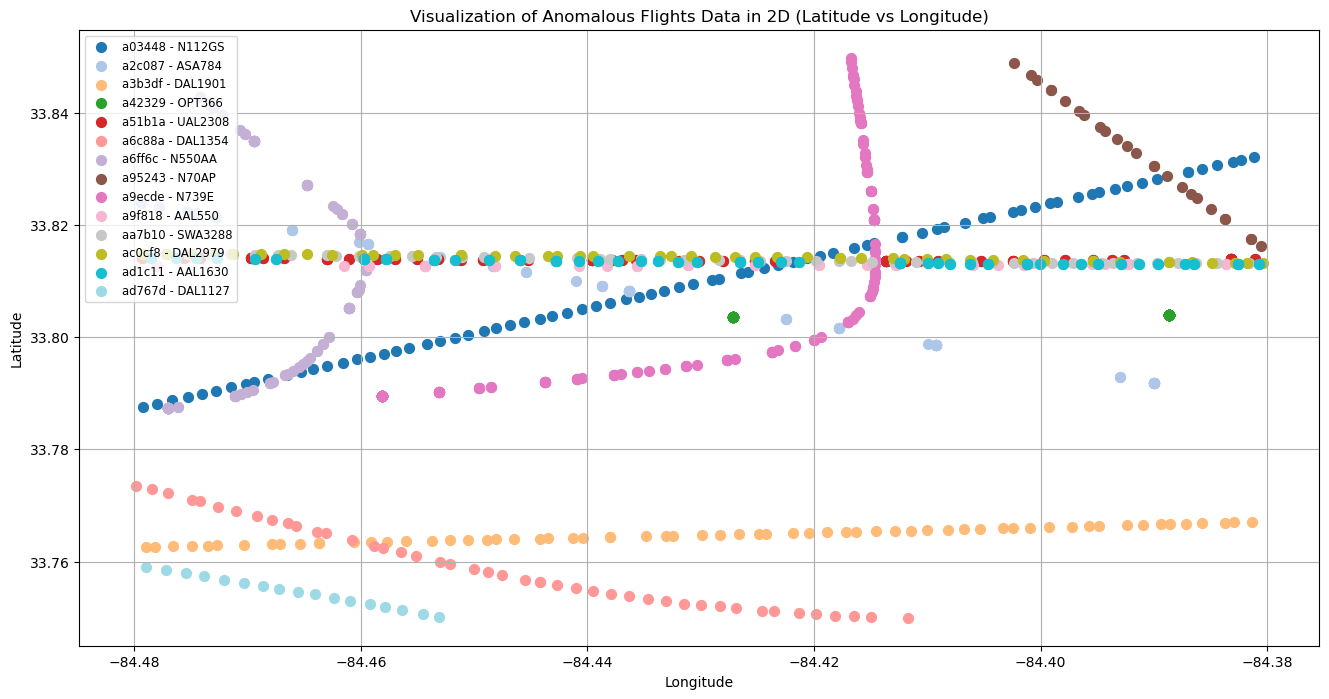

In [86]:
unique_flights = anormal_df_f[['icao24', 'callsign']].drop_duplicates()
num_flights = len(unique_flights)
color_map = plt.cm.get_cmap('tab20', lut=num_flights)

fig, ax = plt.subplots(figsize=(16, 8))
for idx, (index, row) in enumerate(unique_flights.iterrows()):
    color = color_map(idx / num_flights)
    flight_data = anormal_df_f[(anormal_df_f['icao24'] == row['icao24']) & (anormal_df_f['callsign'] == row['callsign'])]
    ax.scatter(flight_data['lon'], flight_data['lat'], c=[color], label=f"{row['icao24']} - {row['callsign']}", s=50)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

legend_handles = []
added_labels = set()
for idx, (index, row) in enumerate(unique_flights.iterrows()):
    if (row['icao24'], row['callsign']) not in added_labels:
        color = color_map(idx / num_flights)
        legend_handles.append(ax.scatter([], [], c=[color], label=f"{row['icao24']} - {row['callsign']}", s=50))
        added_labels.add((row['icao24'], row['callsign']))

ax.legend(handles=legend_handles, loc='upper left', fontsize='small')
plt.title('Visualization of Anomalous Flights Data in 2D (Latitude vs Longitude)')
plt.grid(True)
plt.show()

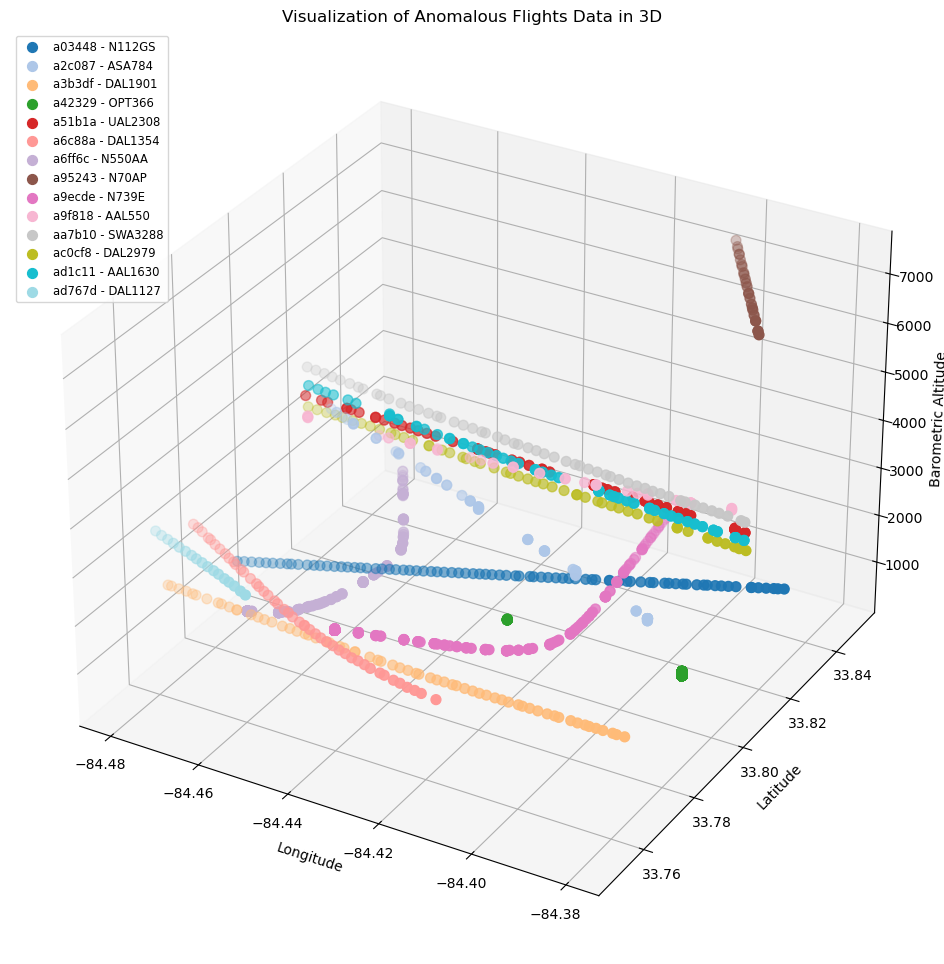

In [88]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection='3d')
legend_handles = []
added_labels = set()

for idx, (index, row) in enumerate(unique_flights.iterrows()):
    color = color_map(idx / num_flights)
    flight_data = anormal_df_f[(anormal_df_f['icao24'] == row['icao24']) & (anormal_df_f['callsign'] == row['callsign'])]
    scatter = ax.scatter(flight_data['lon'], flight_data['lat'], flight_data['baroaltitude'], c=[color], label=f"{row['icao24']} - {row['callsign']}", s=50)
    if (row['icao24'], row['callsign']) not in added_labels:
        legend_handles.append(scatter)
        added_labels.add((row['icao24'], row['callsign']))

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Barometric Altitude')
ax.legend(handles=legend_handles, loc='upper left', fontsize='small')

plt.title('Visualization of Anomalous Flights Data in 3D')
plt.grid(True)
plt.show()


### Normal Filght

In [35]:
def get_unique_pairs(df):
    unique_pairs = df[['icao24', 'callsign']].drop_duplicates()
    unique_pairs_list = list(unique_pairs.itertuples(index=False, name=None))
    return unique_pairs_list

unique_pairs_org = get_unique_pairs(data_after_del)

print("Number of unique pairs:", len(unique_pairs_org))
print("Unique pairs:")
unique_pairs_org

Number of unique pairs: 173317
Unique pairs:


[('a1fb8f', '9211'),
 ('a1e18e', '1310'),
 ('a94b51', 'UAL1417'),
 ('abef98', 'SWA3448'),
 ('a12ce9', 'N175MX'),
 ('a87cbb', 'NKS929'),
 ('0c20b9', 'CMP235'),
 ('a7db08', 'NKS596'),
 ('abe056', 'SWA1706'),
 ('aa7abd', 'UAL725'),
 ('aa140f', 'ABX3103'),
 ('aa8aae', 'N779CF'),
 ('a923cf', 'UAL2005'),
 ('abe3c8', 'SWA3814'),
 ('a1e5f8', '876'),
 ('a2189c', '1690'),
 ('ad2c19', 'AAL1333'),
 ('a98b76', '1310'),
 ('0c20b9', 'CMP236'),
 ('ac5cd7', 'AAL1463'),
 ('aa6c57', '3496'),
 ('a662a5', 'NKS718'),
 ('a83782', 'UAL206'),
 ('a2189c', '1691'),
 ('a1c8eb', '1325'),
 ('a4455e', 'UAL1603'),
 ('aa140f', 'ABX3104'),
 ('a5a910', 'N464GR'),
 ('a8d327', 'NKS220'),
 ('a19372', 'EJA200'),
 ('aa96be', '310'),
 ('aab09a', '684'),
 ('ab23b5', 'DAL712'),
 ('a81163', 'NKS912'),
 ('a6bcc8', 'NKS728'),
 ('a7265b', 'N56UH'),
 ('aa779d', 'SWA1119'),
 ('abdd4a', 'SWA538'),
 ('a1ba0f', '1949'),
 ('aa7e7a', 'UAL651'),
 ('a6cffc', 'AAL725'),
 ('abd254', 'SWA3391'),
 ('a8553c', 'NKS124'),
 ('a1f11d', '1722'),
 ('a

In [36]:
def remove_outliers_and_emergencies(unique_pairs, outliers_pairs, ef_grouped_pairs):
    """
    Tạo danh sách test_pairs từ unique_pairs nhưng loại bỏ các cặp trong outliers_pairs và ef_grouped_pairs.

    Args:
    unique_pairs (list of tuples): Danh sách các cặp (icao24, callsign) duy nhất.
    outliers_pairs (list of tuples): Danh sách các cặp (icao24, callsign) bị coi là outliers.
    ef_grouped_pairs (list of tuples): Danh sách các cặp (icao24, callsign) có mã squawk nguy hiểm.

    Returns:
    list: Danh sách các cặp (icao24, callsign) không có trong outliers_pairs và ef_grouped_pairs.
    """
    pairs_to_remove = set(outliers_pairs) | set(ef_grouped_pairs)
    test_pairs = [pair for pair in unique_pairs if pair not in pairs_to_remove]

    return test_pairs

unique_pairs_org = list(data_after_del[['icao24', 'callsign']].drop_duplicates().itertuples(index=False, name=None))
outliers_pairs = list(all_outliers[['icao24', 'callsign']].drop_duplicates().itertuples(index=False, name=None))
ef_grouped_pairs = list(ef_grouped[['icao24', 'callsign']].drop_duplicates().itertuples(index=False, name=None))

new_pairs = remove_outliers_and_emergencies(unique_pairs_org, outliers_pairs, ef_grouped_pairs)

print("Number of test pairs:", len(new_pairs))
print("Test pairs:")
new_pairs


Number of test pairs: 139425
Test pairs:


[('a1fb8f', '9211'),
 ('a1e18e', '1310'),
 ('a94b51', 'UAL1417'),
 ('abef98', 'SWA3448'),
 ('a12ce9', 'N175MX'),
 ('a87cbb', 'NKS929'),
 ('0c20b9', 'CMP235'),
 ('a7db08', 'NKS596'),
 ('abe056', 'SWA1706'),
 ('aa7abd', 'UAL725'),
 ('aa8aae', 'N779CF'),
 ('a923cf', 'UAL2005'),
 ('abe3c8', 'SWA3814'),
 ('a1e5f8', '876'),
 ('a2189c', '1690'),
 ('ad2c19', 'AAL1333'),
 ('a98b76', '1310'),
 ('0c20b9', 'CMP236'),
 ('ac5cd7', 'AAL1463'),
 ('aa6c57', '3496'),
 ('a662a5', 'NKS718'),
 ('a83782', 'UAL206'),
 ('a2189c', '1691'),
 ('a1c8eb', '1325'),
 ('a4455e', 'UAL1603'),
 ('aa140f', 'ABX3104'),
 ('a5a910', 'N464GR'),
 ('a8d327', 'NKS220'),
 ('aa96be', '310'),
 ('aab09a', '684'),
 ('a81163', 'NKS912'),
 ('a6bcc8', 'NKS728'),
 ('a7265b', 'N56UH'),
 ('aa779d', 'SWA1119'),
 ('abdd4a', 'SWA538'),
 ('a1ba0f', '1949'),
 ('aa7e7a', 'UAL651'),
 ('a6cffc', 'AAL725'),
 ('abd254', 'SWA3391'),
 ('a8553c', 'NKS124'),
 ('a1f11d', '1722'),
 ('ac8a66', 'AAL1514'),
 ('aaa2b0', '634'),
 ('0c2047', 'CMP235'),
 ('abd5

In [37]:
new_df = data_after_del[data_after_del[['icao24', 'callsign']].apply(tuple, axis=1).isin(new_pairs)]
new_df

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
0,1478875626,a1fb8f,33.755679,-84.465466,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
1,1478875627,a1fb8f,33.757645,-84.465917,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
2,1478875628,a1fb8f,33.758743,-84.466198,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
3,1478875629,a1fb8f,33.761536,-84.466870,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11590.02,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
4,1478875630,a1fb8f,33.763733,-84.467411,227.710488,348.664682,0.00000,9211,False,False,False,706.0,11582.40,12031.98,1.478876e+09,1.478876e+09,1.478873e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13351477,1585086698,a6b009,33.830887,-84.475390,92.772669,245.424573,9.75360,N53WA,False,False,False,7171.0,4846.32,4991.10,1.585087e+09,1.585087e+09,1.585084e+09
13351478,1585086699,a6b009,33.830535,-84.476280,92.772669,245.424573,9.75360,N53WA,False,False,False,7171.0,4861.56,5006.34,1.585087e+09,1.585087e+09,1.585084e+09
13351479,1585086700,a6b009,33.830210,-84.477081,92.772669,245.424573,9.42848,N53WA,False,False,False,7171.0,4869.18,5013.96,1.585087e+09,1.585087e+09,1.585084e+09
13351480,1585086701,a6b009,33.829791,-84.478168,92.521291,245.002353,9.42848,N53WA,False,False,False,7171.0,4884.42,5029.20,1.585087e+09,1.585087e+09,1.585084e+09


In [38]:
new_df.to_csv('new_df.csv', index=False)